# 06 - 3DVar error assumptions: innovation Gaussianity

Offline 3DVar minimises, per time step,

$$J(x) = \tfrac12 (x - x_b)^\top B^{-1} (x - x_b) + \tfrac12 (y - Hx)^\top R^{-1} (y - Hx).$$

Under $e_b \sim N(0,B)$, $e_o \sim N(0,R)$, $e_b \perp e_o$, and linear $H$, the innovation
$d(k) = y(k) - H_k x_b(k)$ satisfies $d(k) \sim N(0,\, H_k B H_k^\top + R_k)$. Each $d(k)$ is a
*different* multivariate Gaussian, so the tractable check is the **marginal** one: standardise
every component by its own predicted sd to $N(0,1)$, pool across all sites and ages, and compare
the pool to the standard normal. Marginal non-Gaussianity implies the joint is non-Gaussian; with
the other three assumptions reasonable, the violated one is $e_b \sim N(0,B)$.

Here $H$ is nearest-cell selection, $\operatorname{diag}(B)$ is the Prior's per-cell temporal
variance, and $\operatorname{diag}(R)$ is the per-site `sse` (already a variance, used directly).

Two backgrounds are run: a **climatological** $x_b$ (the per-cell time mean, constant across $k$)
and a **per-age** $x_b(k)$ (the LOVECLIM snapshot at $k$). Three coordinate scorings are run for
each: **raw**, **anomaly** (subtract per-cell / per-site mean), and **normalised** (also divide by
std). Anomaly and normalised produce identical standardised innovations by construction, so their
agreement is used as a correctness check on the transforms.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.insert(0, os.path.abspath(".."))  # allow `from paleoreco...` when run from notebooks/

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from paleoreco.data import build_prior_cube, compute_zscore_stats, GRID_SHAPE
from paleoreco import assim
from paleoreco.assim import scoring as sc
from paleoreco.eval import plot_innovation_gaussianity, plot_pairwise_gaussianity

plt.rcParams["figure.dpi"] = 110
DATA = "../data"

FIG_DIR = Path("../outputs/figures/06_da_assumptions")
FIG_DIR.mkdir(parents=True, exist_ok=True)


## Build once: Prior cube, background B, observation network

`sigma_x` is taken as `sqrt(diag B)` so the per-cell std used to normalise the state matches the
std the observation operator scale uses; the marginal test reads only `diag(B)`, not full B.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]
n_ages = len(ages)

stats_z = compute_zscore_stats(cube, np.arange(n_ages), valid)  # all ages: this is a diagnostic
mean_flat = stats_z["mean"].ravel().astype(float)
safe_flat = np.broadcast_to(stats_z["safe_valid"], (2,) + GRID_SHAPE).ravel()

B = assim.background_covariance(cube, np.arange(n_ages))
diagB = assim.background_variance(B)
sigma_x = np.sqrt(diagB)

long = assim.load_observations(f"{DATA}/Observation.csv")
# One row per physical sample (nearest its central date): the raw table replicates
# each sample across its dating window, which would pseudo-replicate wide-dated
# samples in the pool. Collapse before site stats so my/sy weight samples equally.
long = assim.collapse_to_samples(long)
long = assim.attach_site_stats(long, assim.observation_site_stats(long))
obs_ages = np.intersect1d(long["age"].unique(), ages)

print(f"cube {cube.shape}, B {B.shape}, {len(obs_ages)} ages carry observations, {len(long)} rows")

cube (804, 2, 32, 64), B (4096, 4096), 749 ages carry observations, 10768 rows


In [3]:
# diag(B) is the per-cell temporal variance: cross-check against np.std (differs only by ddof).
assert np.allclose(sigma_x[safe_flat], stats_z["std"].ravel()[safe_flat], rtol=3e-3)
# observation ages lie exactly on the Prior age grid, so nearest-age selection is exact.
assert np.isin(obs_ages, ages).all()

## Pool standardised innovations

For each age with observations: gather the nearest valid cells, score state and observations,
form the innovation, divide by its predicted sd, and collect the resulting $z$. Observations whose
nearest cell is degenerate (masked) or whose site has zero temporal spread (`sy = 0`, unusable
under normalised scoring) are dropped, keeping the same rows across all scorings.

In [4]:
def pool_z(kind, mode):
    """Standardised innovations and their channel labels, pooled over all ages."""
    zs, chans = [], []
    for age in obs_ages:
        ai = int(np.searchsorted(ages, age))
        o = assim.observations_at_age(long, int(age))
        g = assim.obs_cell_index(o["lat"], o["lon"], o["channel"], lats, lons)
        keep = safe_flat[g] & (o["sy"] > 1e-8)
        if not keep.any():
            continue
        g = g[keep]
        y, sse, my, sy = o["y"][keep], o["sse"][keep], o["my"][keep], o["sy"][keep]
        xb = assim.background_state(cube, stats_z["mean"], ai, kind)
        xb_s = sc.score(xb, mean_flat, sigma_x, mode)
        y_s = sc.score(y, my, sy, mode)
        pv = diagB[g]
        scale = assim.obs_operator_scale(pv, sy, mode)
        d = assim.innovation(y_s, xb_s, g, scale)
        zs.append(assim.standardise(d, assim.predicted_sd(pv, sse, sy, mode)))
        chans.append(o["channel"][keep])
    return np.concatenate(zs), np.concatenate(chans)


backgrounds = ["climatological", "per_age"]
results = {(kind, mode): pool_z(kind, mode) for kind in backgrounds for mode in sc.SCORINGS}

In [5]:
# Correctness check: anomaly and normalised standardised innovations are identical.
for kind in backgrounds:
    za, _ = results[(kind, "anomaly")]
    zn, _ = results[(kind, "normalised")]
    assert np.allclose(za, zn, atol=1e-8), f"anomaly != normalised for {kind}"

summary = pd.DataFrame([
    {"background": kind, "scoring": mode, "n": z.size, "mean": z.mean(), "sd": z.std(),
     "skew": stats.skew(z), "exkurt": stats.kurtosis(z)}
    for (kind, mode), (z, _) in results.items()
])
summary.round(3)

,background,scoring,n,mean,sd,skew,exkurt
0,climatological,raw,10768,-5.253,7.382,-0.585,0.739
1,climatological,anomaly,10768,0.024,1.802,0.524,12.601
2,climatological,normalised,10768,0.024,1.802,0.524,12.601
3,per_age,raw,10768,-5.263,7.381,-0.582,0.723
4,per_age,anomaly,10768,0.015,1.836,0.484,11.177
5,per_age,normalised,10768,0.015,1.836,0.484,11.177


## Pooled and per-channel distributions vs N(0,1)

Pooled is the headline; mtco and mtwa are shown separately because pooling can cancel
channel-specific skew or tails.

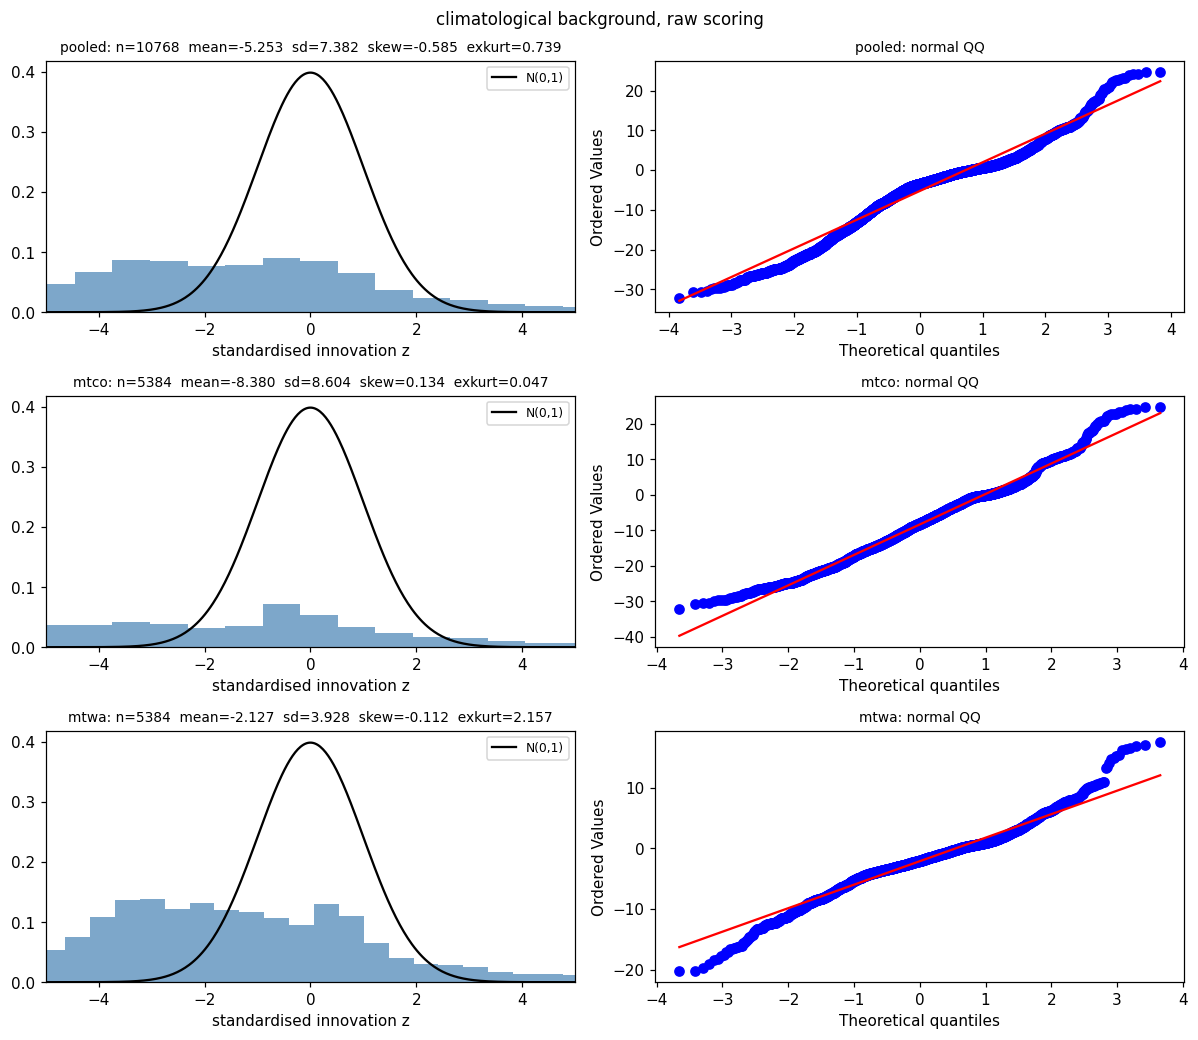

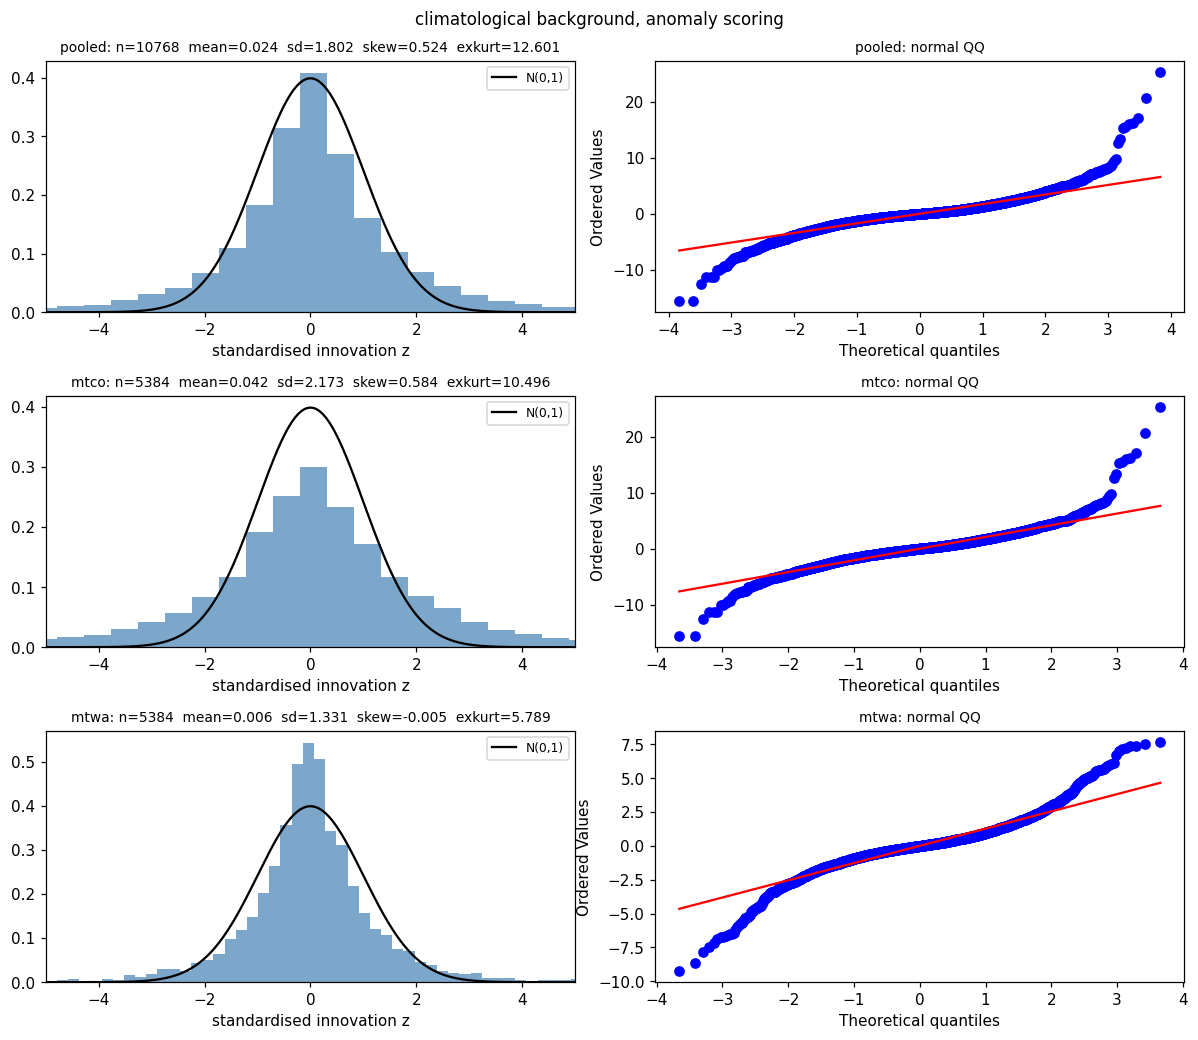

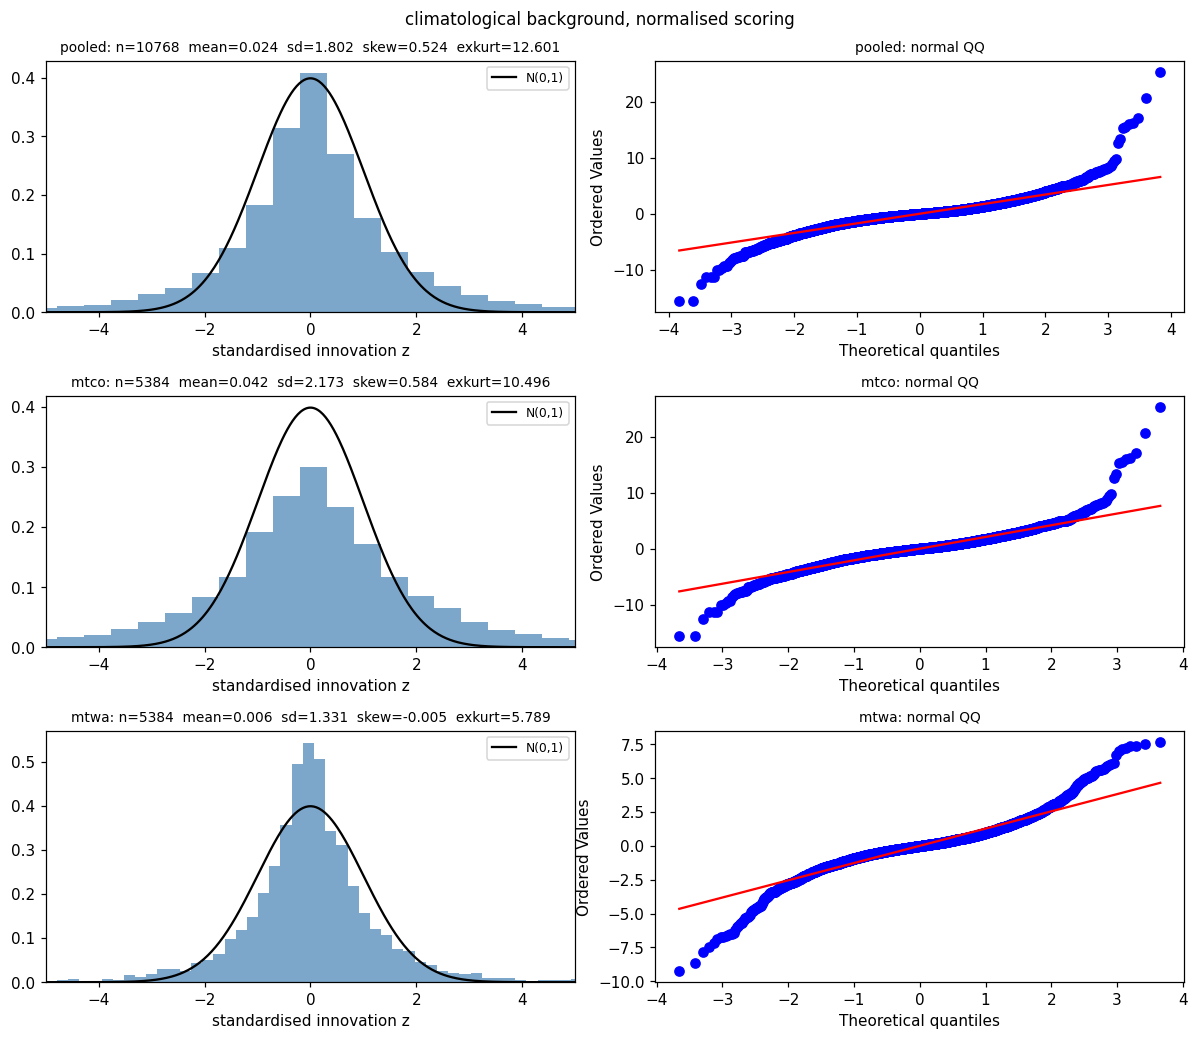

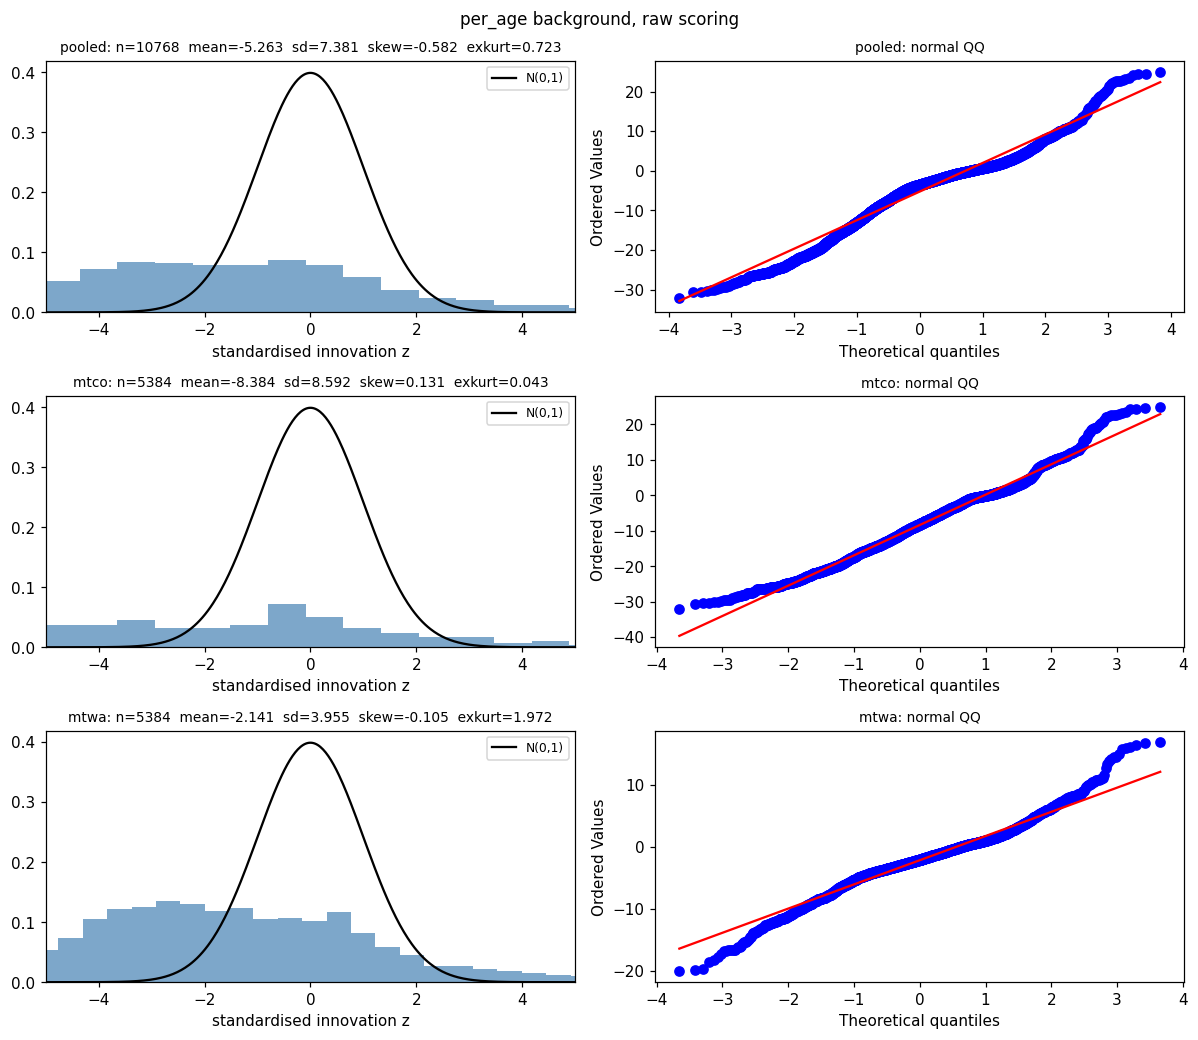

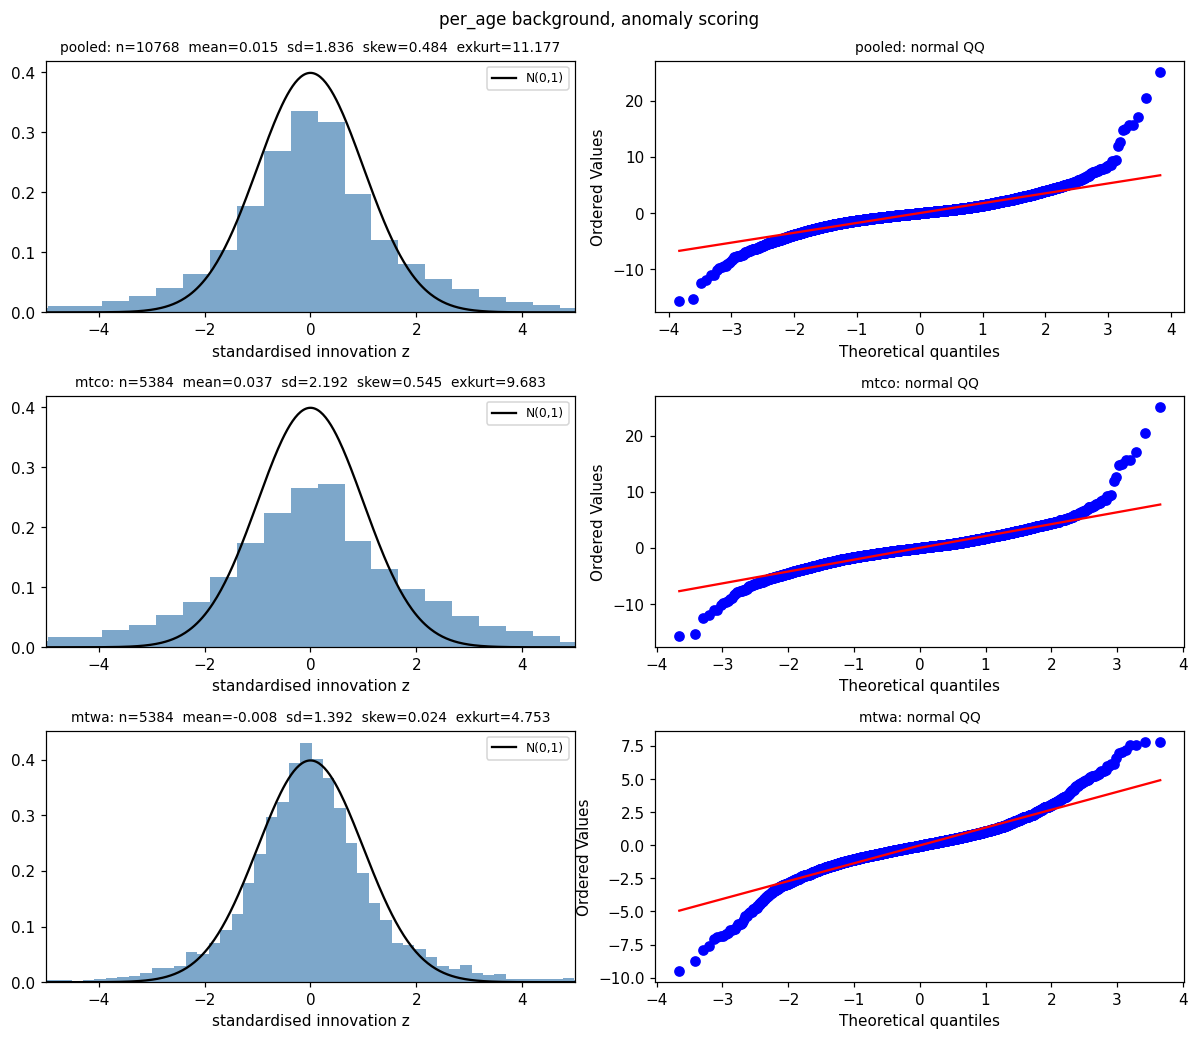

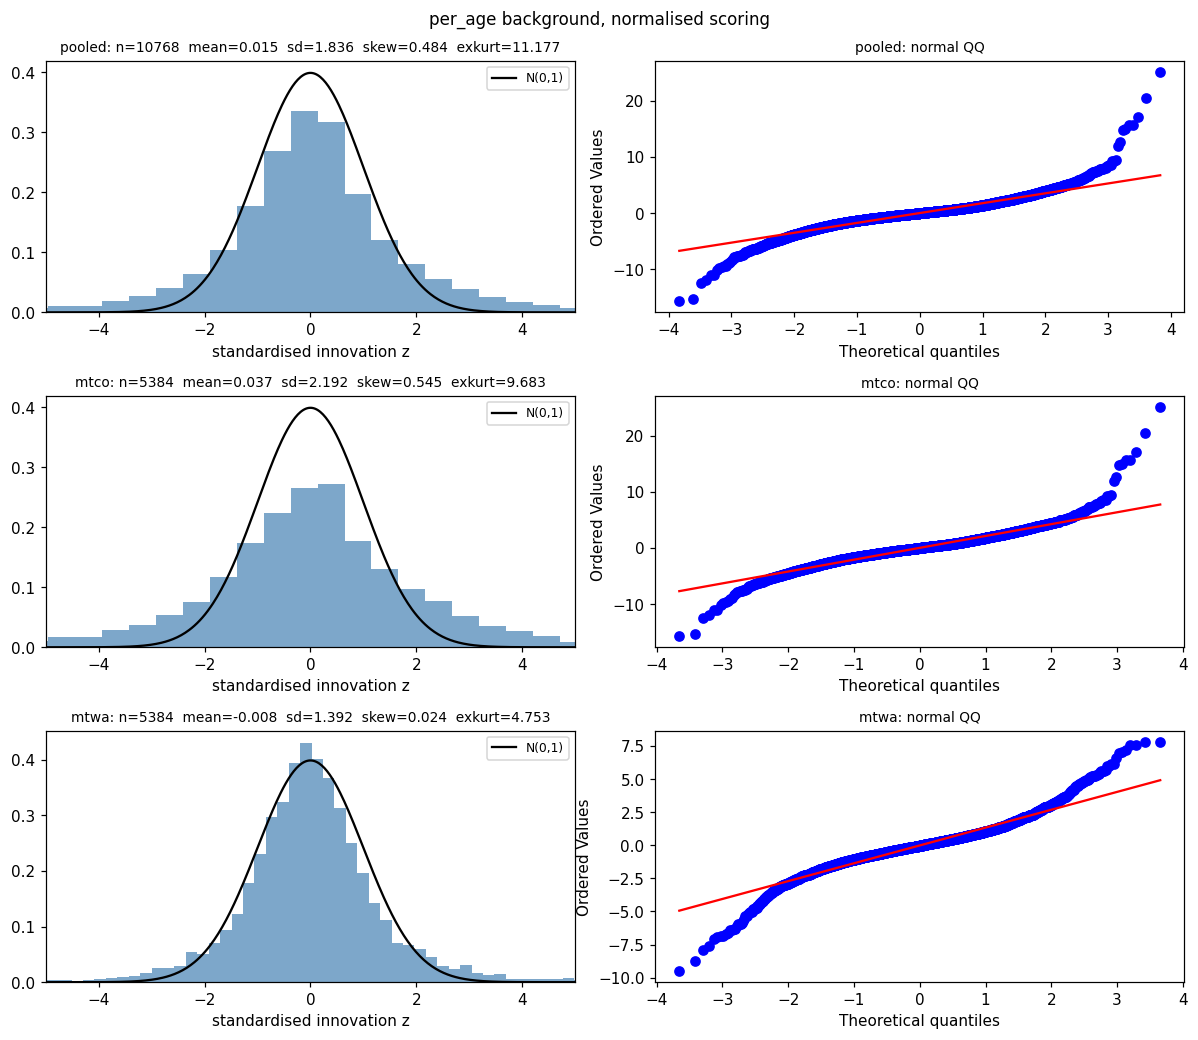

In [6]:
def by_channel(z, ch):
    return {"pooled": z, "mtco": z[ch == "mtco"], "mtwa": z[ch == "mtwa"]}


for kind in backgrounds:
    for mode in sc.SCORINGS:
        z, ch = results[(kind, mode)]
        plot_innovation_gaussianity(
            by_channel(z, ch),
            title=f"{kind} background, {mode} scoring",
            save_path=str(FIG_DIR / f"{kind}_{mode}.png"),
        )
        plt.show()


## Observations

Read the summary table and panels directly. Points to note when reading them:

- Anomaly and normalised columns coincide (correctness check passed); raw differs from anomaly
  only by a location shift carrying the LOVECLIM background bias.
- The pooled standard deviation reports how far the realised innovation spread sits from the
  predicted $\sqrt{\operatorname{diag}(HBH^\top + R)}$; a value far from 1 indicates B and R do not
  jointly explain the spread.
- Skew and excess kurtosis quantify departures from the standard normal; compare the per-channel
  values against the pooled ones.

## 2D joint Gaussianity: whitened component pairs

The marginal test probes one component at a time. This adds the joint check on **component pairs**.
For a pair $(A,B)$ the innovation pair is whitened by its own $2\times2$ predicted covariance
$\Sigma_{\text{pair}}(k) = H_k B H_k^\top + R_k$ restricted to the pair (off-diagonal $= B[g_A, g_B]$,
the prior cross-covariance), so each whitened pair is $N(0,I)$ under the joint-Gaussian assumption.
Pooled over the ages both components are observed, the scatter is a round isotropic blob iff that
assumption holds. A clean blob is a valid, reportable outcome; any departure (clustering, a crescent,
heavy radial tails) is the signal, read off from whatever the data shows.

Anomaly scoring only, on both backgrounds. The six pairs shown are those with the most co-observed
ages, restricted to distinct cells so no cell pair repeats across panels; near-collinear pairs
($|\rho| \to 1$) are excluded only because their $2\times2$ whitening is ill-conditioned. Each panel
draws the $N(0,I)$ reference contours; the companion plot is a $\chi^2(2)$ QQ of the squared radius
$z_1^2+z_2^2$, its distribution under $N(0,I)$.

In [7]:
# Take the pairs with the most co-observed ages, walking down by sample size and
# accepting a pair only if neither cell is already used. The distinct-cell rule
# stops one heavily-sampled cell recurring across panels (many sites share a cell,
# so the same cell pair otherwise reappears, including with sites swapped).
# Near-collinear pairs (|rho| -> 1) are excluded only as ill-conditioned to whiten.
ranked = assim.rank_pairs(long, lats, lons, B, sigma_x, safe_flat)
cand = ranked[ranked["rho"].abs() < 0.99].sort_values("n_shared", ascending=False)

used, rows = set(), []
for _, r in cand.iterrows():
    if int(r["gA"]) in used or int(r["gB"]) in used:
        continue
    rows.append(r)
    used.update([int(r["gA"]), int(r["gB"])])
    if len(rows) == 6:
        break
chosen = pd.DataFrame(rows).reset_index(drop=True)
chosen[["siteA", "chanA", "gA", "siteB", "chanB", "gB", "rho", "n_shared"]].round(3)


,siteA,chanA,gA,siteB,chanB,gB,rho,n_shared
0,73,mtwa,3552,73,mtco,1504,0.943,229
1,86,mtwa,3512,86,mtco,1464,0.610,212
2,70,mtwa,2578,70,mtco,530,0.750,209
3,308,mtwa,3529,308,mtco,1481,0.277,118
4,29,mtwa,3448,29,mtco,1400,0.632,110
5,324,mtco,1586,324,mtwa,3634,0.675,107


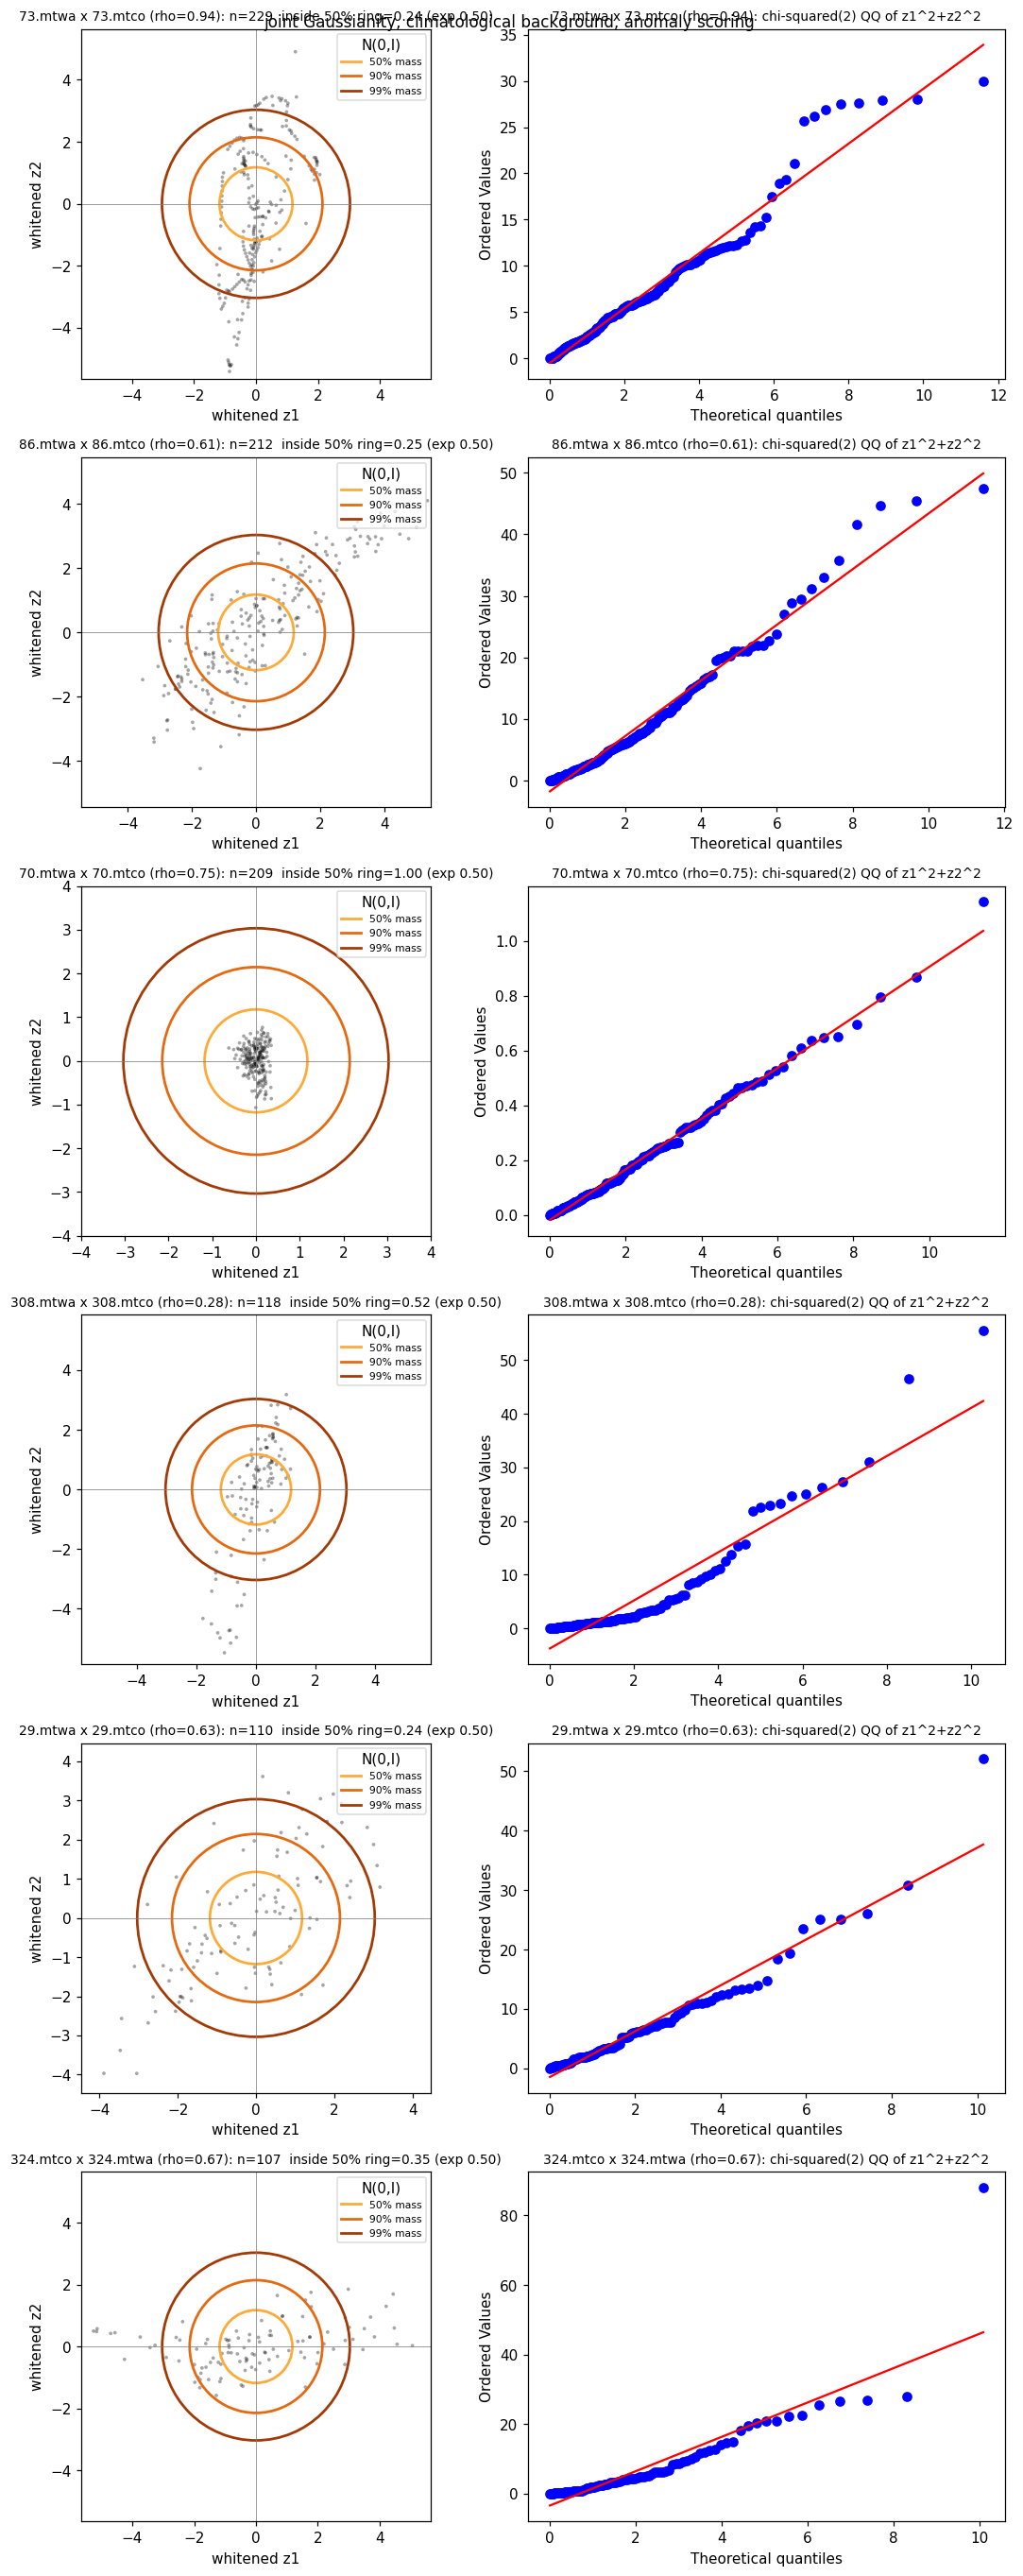

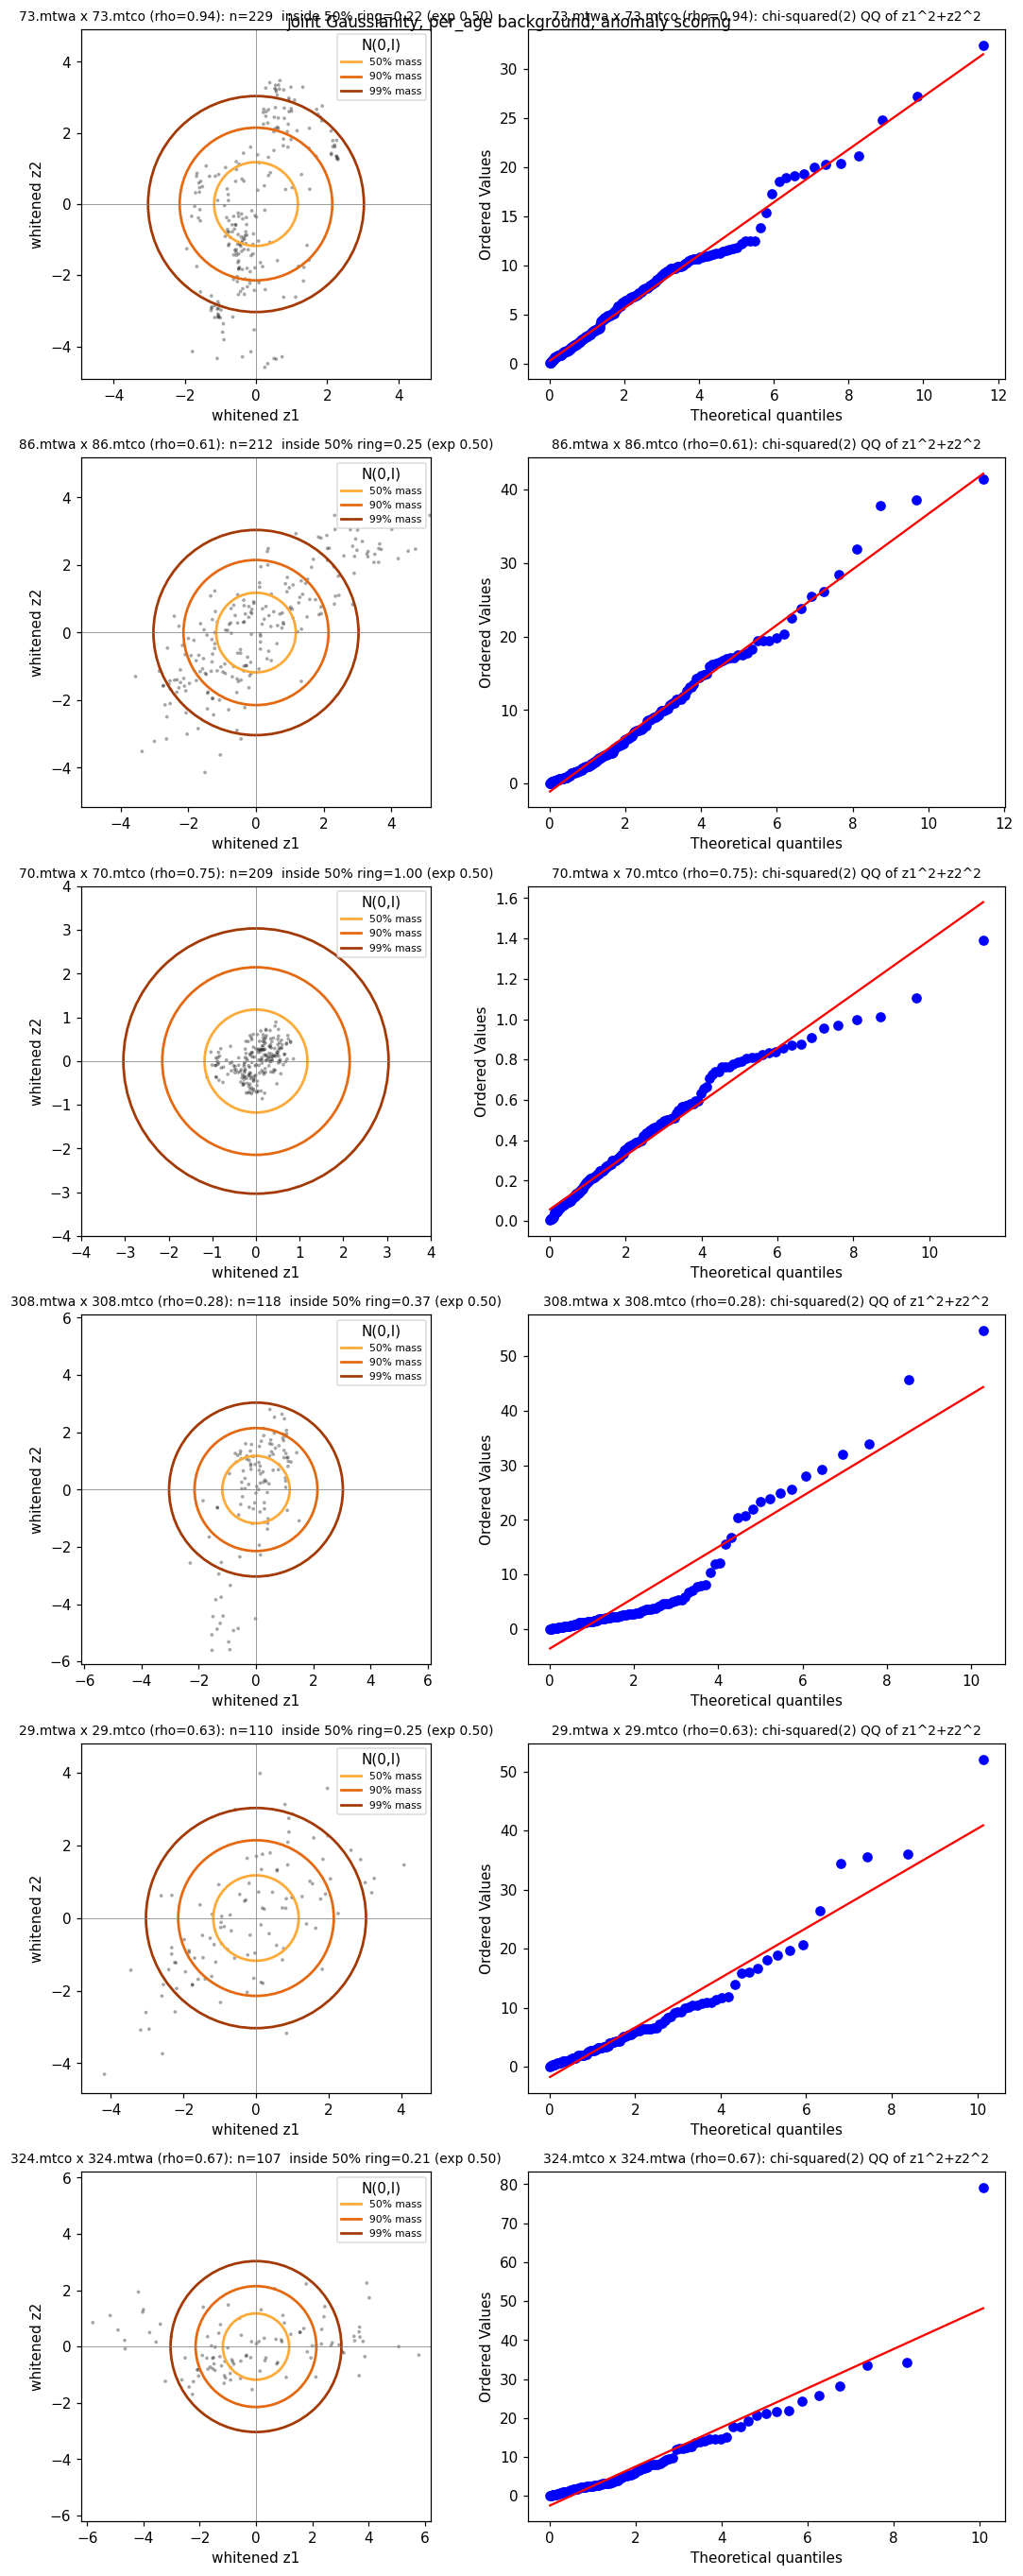

In [8]:

# Whiten each chosen pair per age and scatter against N(0,I).
for kind in backgrounds:
    panels = {}
    for _, r in chosen.iterrows():
        z, _ages = assim.whitened_pair(
            r, long=long, cube=cube, ages=ages, mean_flat=mean_flat,
            diagB=diagB, B=B, kind=kind,
        )
        label = f"{int(r['siteA'])}.{r['chanA']} x {int(r['siteB'])}.{r['chanB']} (rho={r['rho']:.2f})"
        panels[label] = z
    plot_pairwise_gaussianity(
        panels,
        title=f"joint Gaussianity, {kind} background, anomaly scoring",
        save_path=str(FIG_DIR / f"joint_{kind}.png"),
    )
    plt.show()


## Prior non-Gaussianity: bimodality of the constant-forcing glacial ensemble

The 3DVar prior assumes $p(x(k)) = N(x_b, B)$, a single multivariate Gaussian. By the Cramer-Wold
device this holds only if *every* 1-D linear projection of the state is univariate Gaussian, so one
visibly non-Gaussian projection falsifies it.

The shape of the glacial state distribution is probed with the Vettoretti et al. (2022) CCSM4 run
at constant 210 ppm CO$_2$, which sits inside the D-O self-oscillation window and alternates
spontaneously between stadial and interstadial states under *fixed* boundary conditions. Its
equilibrated decades sample one stationary distribution, free of the non-stationary drift that
makes the LOVECLIM transient unpoolable.

The spin-up is discarded (first ~288 decades, to model-year ~5000), the remaining ~500 states are
demeaned into anomalies, and their leading principal components (the 1-D projections) are plotted.
This is a motivating look, not a formal test: bimodal leading PCs are visible by eye and are enough
to show a single Gaussian $B$ cannot represent this distribution.

In [9]:
from paleoreco.data.equilibrium import load_equilibrium_run, state_fields
from paleoreco.eval import pca_scores

# Vettoretti et al. 2022 CCSM4 run, constant 210 ppm CO2 (inside the D-O window).
run = load_equilibrium_run(f"{DATA}/cesmi6gat31rblc210_surfacetemp.npz")

# Drop the spin-up: the ocean settles for ~3000 yr after branching, so only the
# equilibrated decades (from ~model-year 5000) sample one stationary distribution.
N_DISCARD = 288
annual = state_fields(run, reduce="annual_mean")[N_DISCARD:]
mtco = state_fields(run, reduce="mtco")[N_DISCARD:]
mtwa = state_fields(run, reduce="mtwa")[N_DISCARD:]
print(f"equilibrated states: {annual.shape[0]}, grid: {tuple(annual.shape[1:])}")

equilibrated states: 500, grid: (48, 96)


explained variance: [0.896 0.037 0.013 0.007]


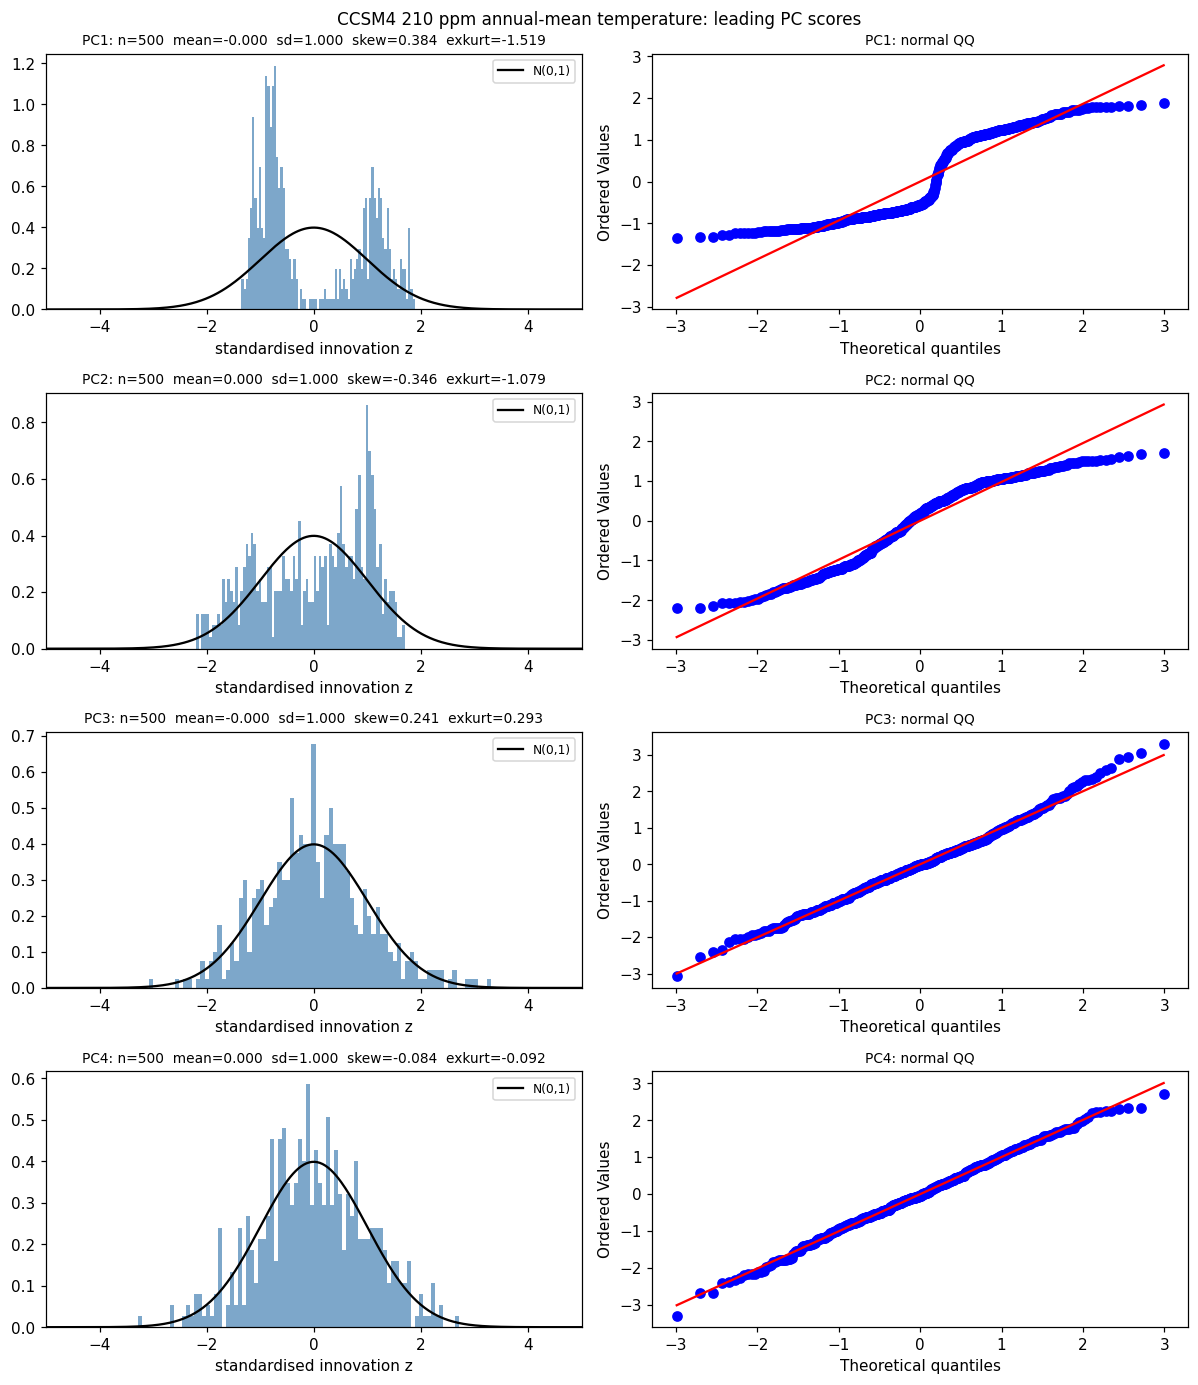

In [10]:
# Annual-mean field: the leading PCs are the dominant directions of the prior covariance.
pa = pca_scores(annual, 4)
print("explained variance:", np.round(pa["explained_variance_ratio"], 3))

# Standardise each PC score so the N(0,1) overlay is comparable; bimodality is
# scale-invariant, so it survives the rescaling.
z = pa["scores"] / pa["scores"].std(axis=0)
plot_innovation_gaussianity(
    {f"PC{i + 1}": z[:, i] for i in range(z.shape[1])},
    title="CCSM4 210 ppm annual-mean temperature: leading PC scores",
    save_path=str(FIG_DIR / "prior_pca_210ppm_annual.png"),
)
plt.show()

explained variance: [0.824 0.028 0.02  0.01 ]


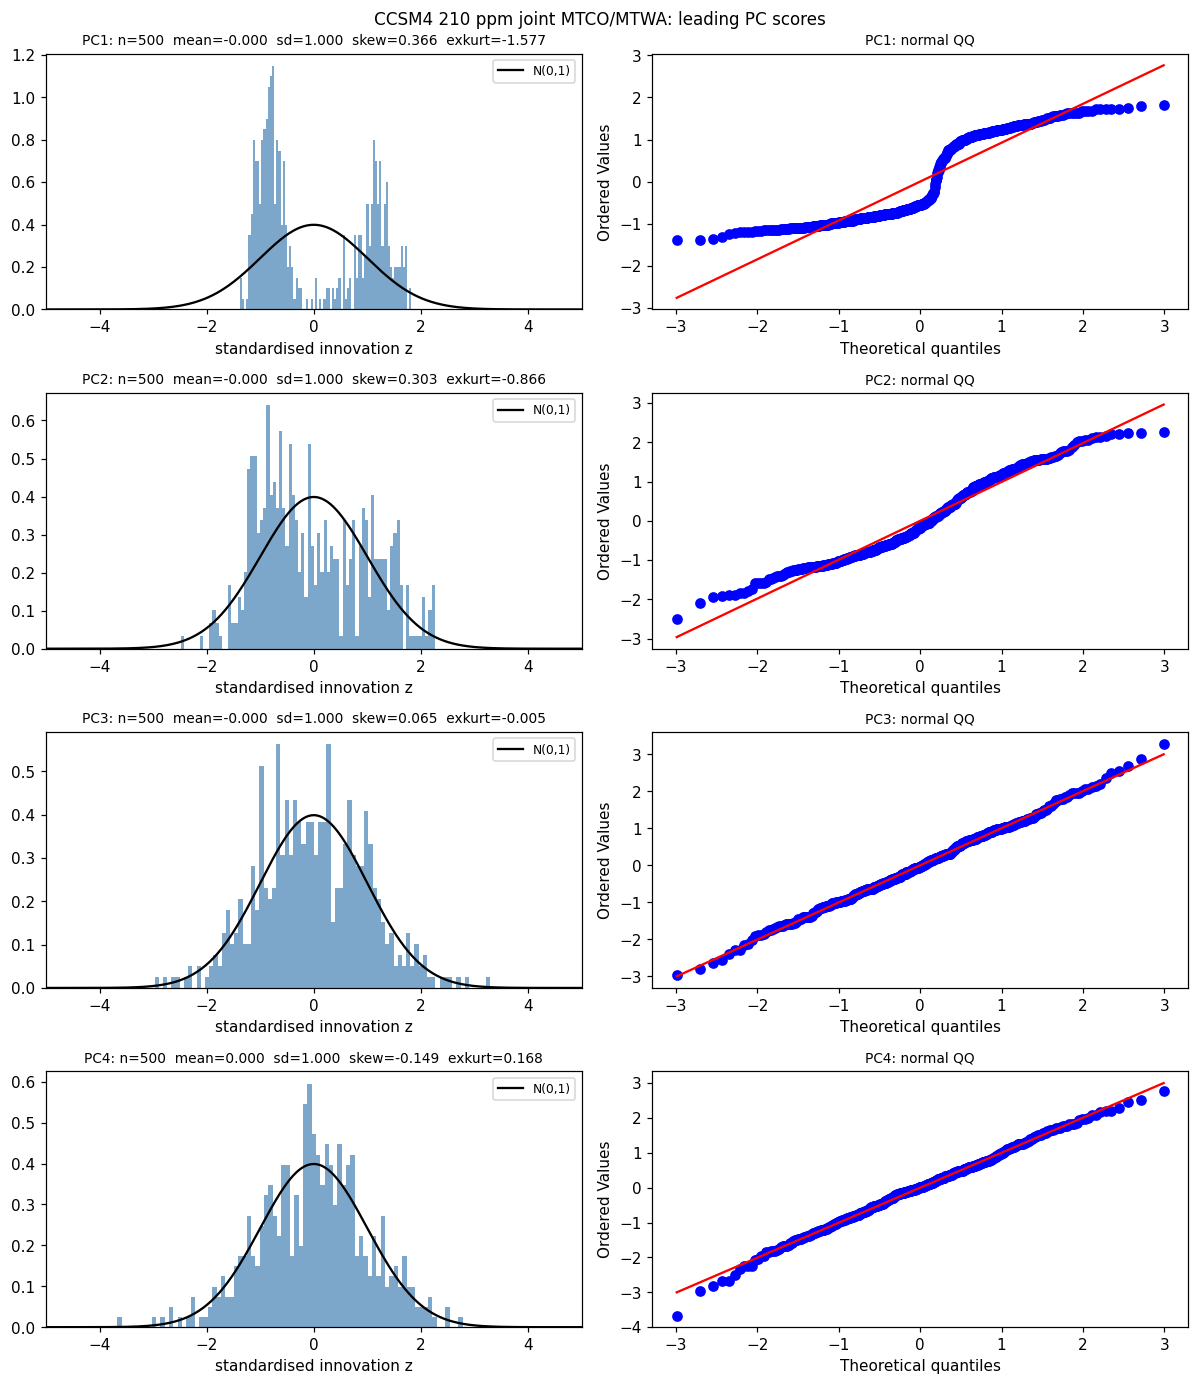

In [11]:
# Joint (MTCO, MTWA) field: the exact state vector the 3DVar prior is placed on.
stack = np.stack([mtco, mtwa], axis=1)  # (n_states, 2, n_lat, n_lon)
pj = pca_scores(stack, 4)
print("explained variance:", np.round(pj["explained_variance_ratio"], 3))

zj = pj["scores"] / pj["scores"].std(axis=0)
plot_innovation_gaussianity(
    {f"PC{i + 1}": zj[:, i] for i in range(zj.shape[1])},
    title="CCSM4 210 ppm joint MTCO/MTWA: leading PC scores",
    save_path=str(FIG_DIR / "prior_pca_210ppm_mtco_mtwa.png"),
)
plt.show()

**Reading.** The leading principal component carries almost all the variance (about 0.9 for the
annual mean, 0.8 for joint MTCO/MTWA), and its score distribution is plainly bimodal: the states
pile into two separated clusters (cold stadial, warm interstadial) with a sparse valley between,
far from the $N(0,1)$ reference. A single multivariate Gaussian cannot reproduce two modes along
its dominant axis.

This is the motivation for a non-Gaussian (generative) prior: the stationary glacial climate
occupies two regimes, so $p(x)$ is a mixture, not a Gaussian, exactly where the 3DVar background
covariance $B$ assumes one mode. Scope: this is the CCSM4 LGM-ice / MIS3-CO$_2$ glacial climate, a
different model from the LOVECLIM prior, so it motivates bimodality of the glacial state
distribution rather than proving it for the LOVECLIM background specifically.

## Negative control: 170 ppm, outside the D-O window

At 170 ppm CO$_2$ the system sits below the ~190-225 ppm oscillation window, locked in a single
stable cold stadial (Vettoretti et al. 2022). If the bimodality at 210 ppm is the D-O regime
structure rather than an artefact of the method, it should switch off here: with no second regime
to visit, the leading PC scores should be unimodal, close to the $N(0,1)$ reference. The same
spin-up trim and projection are applied as above.

In [12]:
# 170 ppm run: below the oscillation window, expected to stay in one stable state.
run170 = load_equilibrium_run(f"{DATA}/cesmi6gat31rblc170i_surfacetemp.npz")
annual170 = state_fields(run170, reduce="annual_mean")[N_DISCARD:]
mtco170 = state_fields(run170, reduce="mtco")[N_DISCARD:]
mtwa170 = state_fields(run170, reduce="mtwa")[N_DISCARD:]
print(f"equilibrated states: {annual170.shape[0]}, grid: {tuple(annual170.shape[1:])}")

equilibrated states: 500, grid: (48, 96)


explained variance: [0.201 0.111 0.081 0.056]


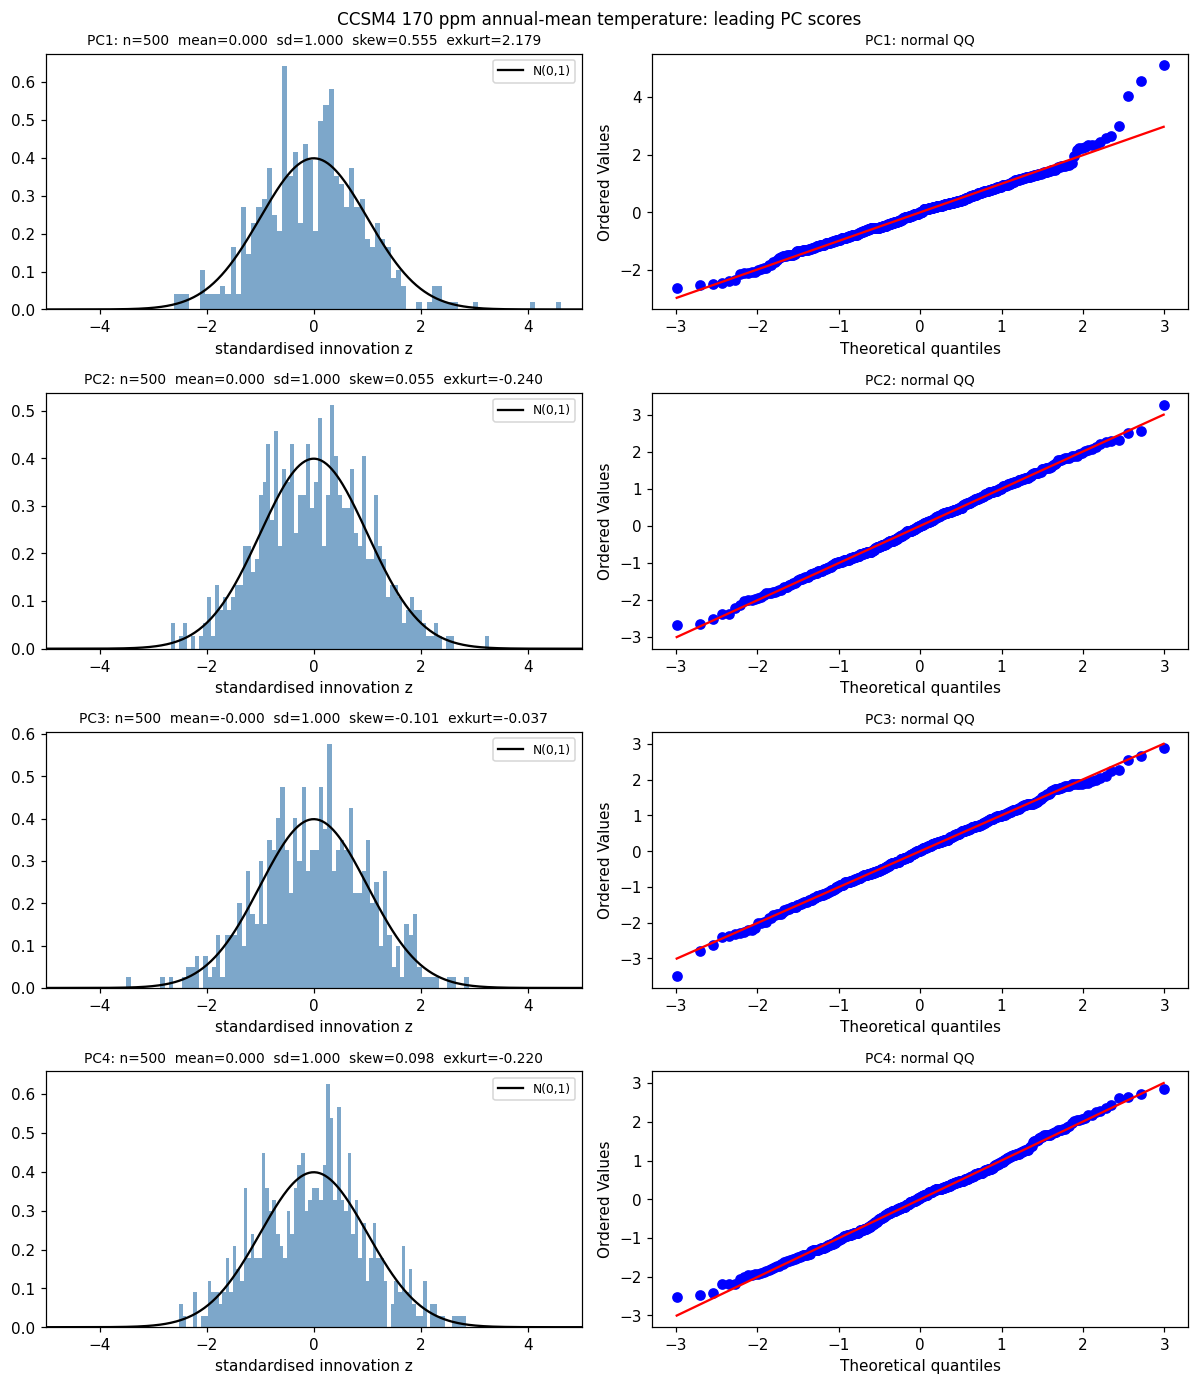

In [13]:
# Annual-mean field, 170 ppm.
pa170 = pca_scores(annual170, 4)
print("explained variance:", np.round(pa170["explained_variance_ratio"], 3))

z170 = pa170["scores"] / pa170["scores"].std(axis=0)
plot_innovation_gaussianity(
    {f"PC{i + 1}": z170[:, i] for i in range(z170.shape[1])},
    title="CCSM4 170 ppm annual-mean temperature: leading PC scores",
    save_path=str(FIG_DIR / "prior_pca_170ppm_annual.png"),
)
plt.show()

explained variance: [0.125 0.079 0.056 0.049]


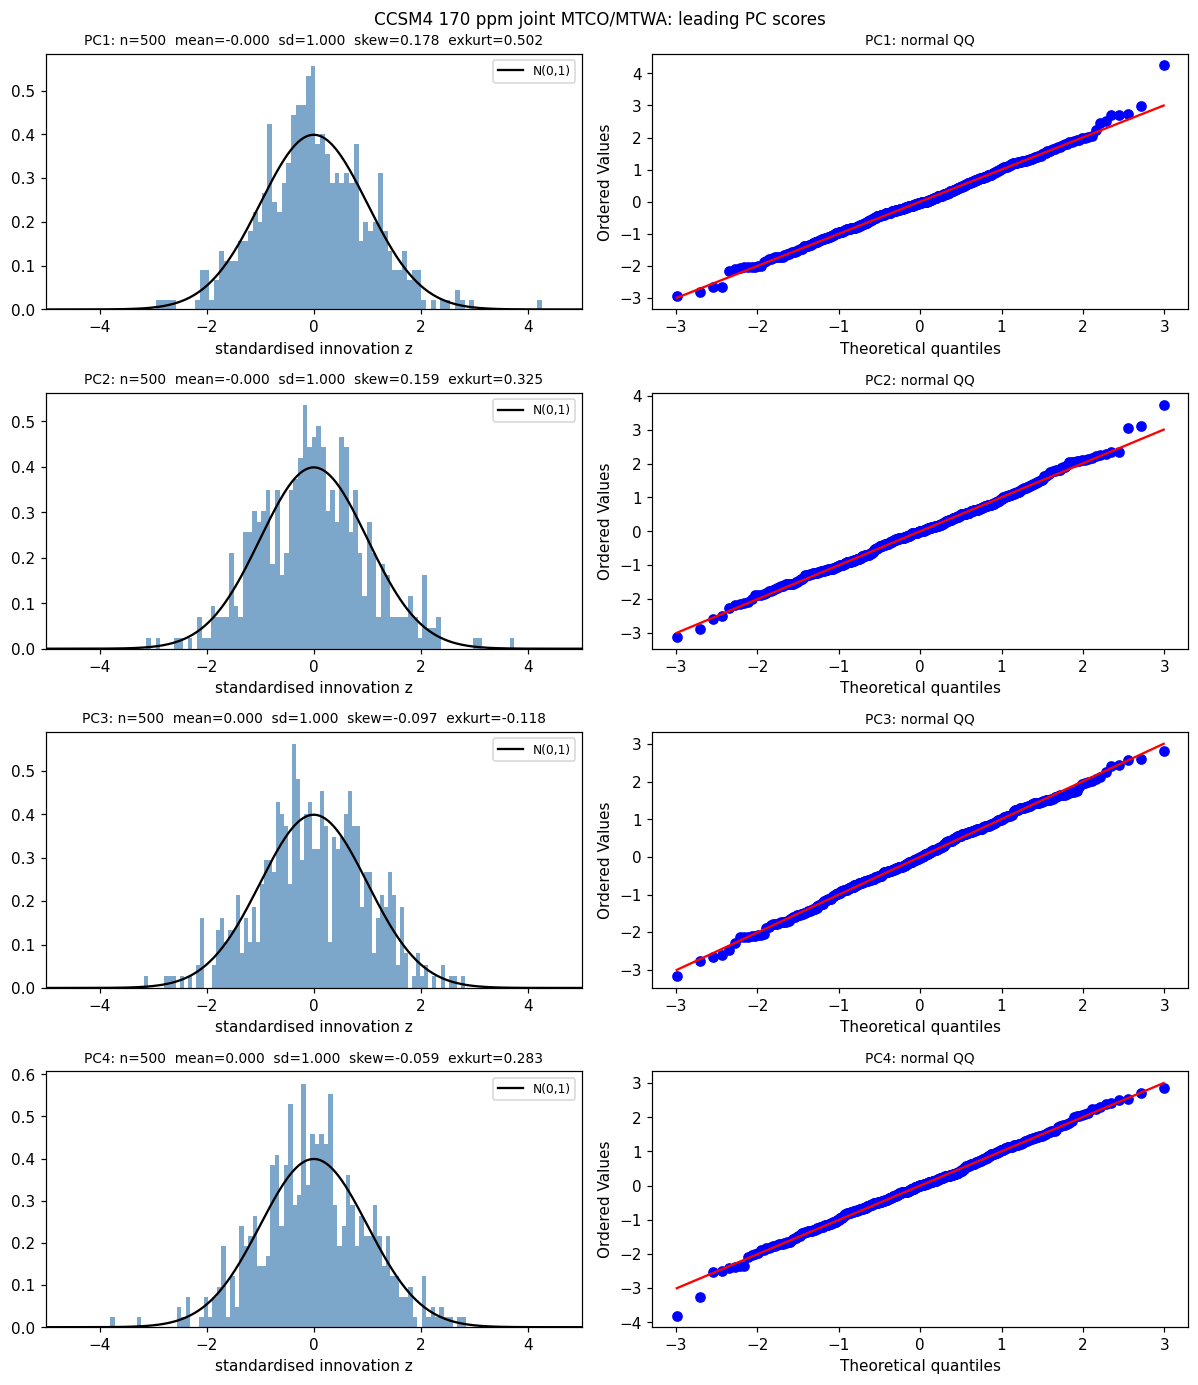

In [14]:
# Joint (MTCO, MTWA) field, 170 ppm.
stack170 = np.stack([mtco170, mtwa170], axis=1)
pj170 = pca_scores(stack170, 4)
print("explained variance:", np.round(pj170["explained_variance_ratio"], 3))

zj170 = pj170["scores"] / pj170["scores"].std(axis=0)
plot_innovation_gaussianity(
    {f"PC{i + 1}": zj170[:, i] for i in range(zj170.shape[1])},
    title="CCSM4 170 ppm joint MTCO/MTWA: leading PC scores",
    save_path=str(FIG_DIR / "prior_pca_170ppm_mtco_mtwa.png"),
)
plt.show()

**Reading.** Outside the window the picture inverts: the leading component no longer dominates
the variance (PC1 falls from ~0.9 to ~0.2, now spread across many comparable modes) and the PC
score distributions are unimodal, close to $N(0,1)$. The bimodality is therefore the D-O regime
structure, controlled by CO$_2$, not an artefact of PCA or the field reduction. This is what makes
the 210 ppm result a statement about the glacial prior rather than a generic property of climate
fields.